In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xml.etree.ElementTree as ET
import xmlschema
import json
import polars as pl
import networkx as nx
from itertools import zip_longest

In [3]:
import ggblab

In [4]:
from ggblab_extra import ConstructionIO
from ggblab_extra import ConstructionTreeParser

In [5]:
from ggblab_extra.sympy import point_from_value, segment_from_command, line_from_value, circle_from_value
from ggblab_extra.sympy import attach_object2d, attach_object3d, enumerate_plane_members

In [6]:
%ggblab api getVersion()

[ggblab] created GeoGebra singleton and stored as 'ggb' in user namespace


'5.2.909.9'

In [7]:
%ggb api newConstruction()

In [8]:
%%ggb
A = Point(xAxis)
B = Point(yAxis)

['A', 'B']

In [9]:
%%ggb
Segment(A, B)

['f']

In [10]:
# %%ggb
# Point(f)
# PathParameter(_)

In [13]:
%%ggb
Line(A, B)

['h']

In [14]:
%%ggb
C = Point(xAxis)
D = Point(yAxis)

['C', 'D']

In [15]:
%%ggb
h = Line(C, D)

['h']

In [16]:
%%ggb
l1 = {Intersect[g, h]}
l1(1)

['l1', 'E']

In [17]:
df = await ConstructionIO.initialize_dataframe(ggb, use_applet=True)
df["Name", "Type", "Command", "Value"]

Name,Type,Command,Value
str,str,str,str
"""A""","""point""","""Point(xAxis)""","""A = (1, 0)"""
"""B""","""point""","""Point(yAxis)""","""B = (0, -1)"""
"""f""","""segment""","""Segment(A, B)""","""f = 1.4142135623731"""
"""g""","""line""","""Line(A, B)""","""g: x - y = 1"""
"""C""","""point""","""Point(xAxis)""","""C = (-1, 0)"""
"""D""","""point""","""Point(yAxis)""","""D = (0, 1)"""
"""h""","""line""","""Line(C, D)""","""h: -x + y = 1"""
"""l1""","""list""","""{Intersect(g, h)}""","""l1 = {?}"""
"""E""","""point""","""l1(1)""","""E = (?, ?)"""


In [54]:
from ggblab_extra.sympy.utils import expr_from_value

In [71]:
r = await ggb.function('getValueString', ['g'])
s = expr_from_value(r)
r, s

('g: x - y = 1', Eq(x - y, 1))

In [91]:
expr_from_value('l1 = {?}')

EmptySet

In [52]:
print_tree(s, assumptions=False)

Equality: Eq(-x + y, 1)
+-Add: -x + y
| +-Symbol: y
| +-Mul: -x
|   +-NegativeOne: -1
|   +-Symbol: x
+-One: 1



In [79]:
print_mathml(s, printer='presentation') # 'content') #

<mrow>
	<mrow>
		<mi>x</mi>
		<mo>-</mo>
		<mi>y</mi>
	</mrow>
	<mo>=</mo>
	<mn>1</mn>
</mrow>



In [50]:
print_mathml(s, printer='content')

<emptyset/>



In [75]:
from sympy import mathml
from IPython.display import Math

In [87]:
display(HTML(mathml(s))) #, printer='presentation')))

In [85]:
from IPython.display import HTML, display

# 数式: x^2 + y^2 = z^2 (MathML)
mathml_code = """
    <math xmlns="http://www.w3.org" display="block">
  <msup>
    <mi>x</mi>
    <mn>2</mn>
  </msup>
  <mo>+</mo>
  <msup>
    <mi>y</mi>
    <mn>2</mn>
  </msup>
  <mo>=</mo>
  <msup>
    <mi>z</mi>
    <mn>2</mn>
  </msup>
</math>
"""

display(HTML(mathml_code))


In [39]:
df2 = attach_object2d(df)
df2["Name", "Type", "object2d"]

Name,Type,object2d
str,str,object
"""A""","""point""","Object2D(kind='point', obj=Point2D(1, 0), value='A = (1, 0)', command='Point(xAxis)')"
"""B""","""point""","Object2D(kind='point', obj=Point2D(0, -1), value='B = (0, -1)', command='Point(yAxis)')"
"""f""","""segment""","Object2D(kind='segment', obj=Segment2D(Point2D(1, 0), Point2D(0, -1)), value='f = 1.4142135623731', command='Segment(A, B)')"
"""g""","""line""","Object2D(kind='line', obj=Line2D(Point2D(0, -1), Point2D(1, 0)), value='g: x - y = 1', command='Line(A, B)')"
"""C""","""point""","Object2D(kind='point', obj=Point2D(-1, 0), value='C = (-1, 0)', command='Point(xAxis)')"
"""D""","""point""","Object2D(kind='point', obj=Point2D(0, 1), value='D = (0, 1)', command='Point(yAxis)')"
"""h""","""line""","Object2D(kind='line', obj=Line2D(Point2D(0, 1), Point2D(-1, 0)), value='h: -x + y = 1', command='Line(C, D)')"
"""l1""","""list""",null
"""E""","""point""","Object2D(kind='point', obj=None, value='E = (?, ?)', command='l1(1)')"


In [42]:
l_1 = df2.filter(pl.col("Name") == "g")["object2d"].item().obj
l_2 = df2.filter(pl.col("Name") == 'h')["object2d"].item().obj

In [43]:
l_1.equation().evalf(), l_2.equation().evalf()

(-x + y + 1.0, x - y + 1.0)

In [44]:
p_1 = list(l_1.intersect(l_2).evalf())[0]
p_1

IndexError: list index out of range

In [47]:
s = linsolve((l_1.equation().evalf(), l_2.equation().evalf()), (x, y))
s

EmptySet

In [179]:
l_1.distance(p_1)

0

In [183]:
l_1.equation().subs({x: p_1[0], y: p_1[1]})

0

In [140]:
r = await ggb.function('getValueString', ['l1'])
ggb.parser.tokenize(r)

['l1', '=', [['-3.9900497512438', '-2.9950248756219']]]

In [130]:
d1 = l_1.equation().evalf().as_coefficients_dict()
d2 = l_1.equation().evalf().as_coefficients_dict()
d1, d2

(defaultdict(int, {1: 2.00000000000000, x: -1, y: 2.00000000000000}),
 defaultdict(int, {1: 2.00000000000000, x: -1, y: 2.00000000000000}))

In [134]:
Matrix([[d1[x], d1[y], 0]]).cross(Matrix([[d2[x], d2[y], 0]]))

Matrix([[0, 0, 0]])

In [103]:
p = ConstructionTreeParser(df)
g1 = p.parse()

In [104]:
labels_map = {}
for n, t in p.df["Name", "Type"].rows():
    g1.nodes[n]["label"] = f"{n} ({t})"
nx.set_node_attributes(g1, labels_map, "label")
nx.write_network_text(g1, with_labels="label")

╟── xAxis
╎   ├─╼ A (point)
╎   │   ├─╼ f (segment) ╾ B (point)
╎   │   ├─╼ g (line) ╾ B (point)
╎   │   ├─╼ v (vector) ╾ u (vector)
╎   │   └─╼ a (vector) ╾ w (vector)
╎   └─╼ C (point)
╎       └─╼ h (line) ╾ D (point)
╟── yAxis
╎   ├─╼ B (point)
╎   │   └─╼  ...
╎   └─╼ D (point)
╎       └─╼  ...
╟── u (vector)
╎   └─╼  ...
╟── w (vector)
╎   └─╼  ...
╙── l1 (list)
    └─╼ E (point)


In [105]:
nx.ancestors(g1, 'A'), nx.descendants(g1, 'A')

({'xAxis'}, {'a', 'f', 'g', 'v'})

In [106]:
nx.ancestors(g1, 'f'), nx.descendants(g1, 'f')

({'A', 'B', 'xAxis', 'yAxis'}, set())

In [107]:
p.roots, p.leaves

(['xAxis', 'yAxis', 'u', 'w', 'l1'], ['f', 'g', 'v', 'a', 'h', 'E'])

In [108]:
for n in p.roots:
    print(list(g1.neighbors(n)))

['A', 'C']
['B', 'D']
['v']
['a']
['E']


In [25]:
from sympy import nonlinsolve, linsolve, solve, Eq, discriminant, Matrix, Poly, srepr, pprint, print_tree
from sympy import print_mathml
from sympy import assuming, ask, Q
from sympy import symbols
x, y, z = symbols('x y z', real=True)
theta = symbols('theta')
pi = symbols('pi')

In [97]:
with assuming(Q.rational(x)):
    print(ask(Q.real(x)))
    # print_tree(x)

True
Symbol: x
commutative: True
complex: True
extended_real: True
finite: True
hermitian: True
imaginary: False
infinite: False
real: True



In [81]:
a = 1
type(a), type(x), x.is_real

(int, sympy.core.symbol.Symbol, True)

In [86]:
x.subs({x: 1}), x

(1, x)

In [87]:
(x+y).subs({x: 2, y: 1})

3

In [73]:
print_tree(x, assumptions=True)

Symbol: x
commutative: True
complex: True
extended_real: True
finite: True
hermitian: True
imaginary: False
infinite: False
real: True



In [32]:
r = await ggb.function('getCommandString', ['f'])
s = segment_from_command(r, df)

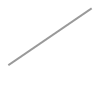

In [33]:
s.evalf()

In [34]:
type(s)

sympy.geometry.line.Segment2D

In [39]:
r = await ggb.function('getValueString', ['g'])
s1 = line_from_value(r)

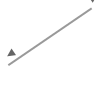

In [40]:
s1.evalf()

In [42]:
type(s1)

ggblab_extra.sympy.line.Line

In [74]:
s1.equation().evalf()

-1.46*x + 2.14*y + 3.1244

In [75]:
print_tree(_, assumptions=False)

Add: -1.46*x + 2.14*y + 3.1244
+-Float: 3.12440000000000
+-Mul: 2.14*y
| +-Float: 2.14000000000000
| +-Symbol: y
+-Mul: -1.46*x
  +-Float: -1.46000000000000
  +-Symbol: x



In [65]:
d1 = s1.equation().evalf().as_coefficients_dict()
d1

defaultdict(int,
            {1: 3.12440000000000, y: 2.14000000000000, x: -1.46000000000000})

In [68]:
# c1 = Poly(s1.equation().evalf(), x, y).as_dict()
# c1

In [69]:
# c1 = Poly(s1.equation().evalf(), x, y).coeffs()
# c1

In [70]:
%%ggb
u = Vector(({d1[x]}, {d1[y]}))
v = Translate(_, A)

['u', 'v']

In [71]:
%%ggb
w = Vector(({d1[y]}, -{d1[x]}))
a = Translate(_, A)

['w', 'a']

In [159]:
%%ggb
{theta} = Slider[0, 2{pi}, 2/90{pi}]

['θ']

In [152]:
p_a = df2.filter(pl.col("Name") == 'A')["object2d"].item().obj

In [156]:
from sympy import symbols, Matrix, cos, sin, pi

In [157]:
m1 = Matrix([[1, 0, p_a[0]], [0, 1, p_a[1]], [0, 0, 1]])
m2 = Matrix([[cos(theta), -sin(theta), 0], [sin(theta), cos(theta), 0], [0, 0, 1]])

In [158]:
%%ggb
m1 = {m1}
m2 = {m2}

['m1', 'm2']

In [16]:
for e in (await ggb.function('getAllObjectNames')):
    print(await ggb.function('getXML', [e]))

<element type="point" label="A">
	<show object="true" label="true"/>
	<objColor r="21" g="101" b="192" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<animation step="0.1" type="1" playing="false"/>
	<pointSize val="5"/>
	<pointStyle val="0"/>
	<coords x="3.31" y="0" z="1"/>
</element>

<element type="point" label="B">
	<show object="true" label="true"/>
	<objColor r="21" g="101" b="192" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<animation step="0.1" type="1" playing="false"/>
	<pointSize val="5"/>
	<pointStyle val="0"/>
	<coords x="0" y="-3.42" z="1"/>
</element>

<element type="segment" label="f">
	<show object="true" label="true"/>
	<objColor r="0" g="0" b="0" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<lineStyle thickness="5" type="0" typeHidden="1" opacity="178"/>
	<eqnStyle style="implicit"/>
	<outlyingIntersections val="false"/>
	<keepTypeOnTransform val="true"/>
	<startStyle val="default"/>
	<endStyle val="default"/>
	<coords x="3.42" y="-3.31" z="-11

In [17]:
r = await ggb.function('getXML')

In [18]:
root = ET.fromstring(r)
x = ET.tostring(root.find('.//construction'), encoding='unicode')
print(x)

<construction title="" author="" date="">
<command name="Point">
	<input a0="xAxis" />
	<output a0="A" />
</command>
<element type="point" label="A">
	<show object="true" label="true" />
	<objColor r="21" g="101" b="192" alpha="0" />
	<layer val="0" />
	<labelMode val="0" />
	<animation step="0.1" type="1" playing="false" />
	<pointSize val="5" />
	<pointStyle val="0" />
	<coords x="3.31" y="0" z="1" />
</element>
<command name="Point">
	<input a0="yAxis" />
	<output a0="B" />
</command>
<element type="point" label="B">
	<show object="true" label="true" />
	<objColor r="21" g="101" b="192" alpha="0" />
	<layer val="0" />
	<labelMode val="0" />
	<animation step="0.1" type="1" playing="false" />
	<pointSize val="5" />
	<pointStyle val="0" />
	<coords x="0" y="-3.42" z="1" />
</element>
<command name="Segment">
	<input a0="A" a1="B" />
	<output a0="f" />
</command>
<element type="segment" label="f">
	<show object="true" label="true" />
	<objColor r="0" g="0" b="0" alpha="0" />
	<layer val

In [19]:
o = ggb.file.ggb_schema.decode(x)
o

{'@title': '',
 '@author': '',
 '@date': '',
 'command': [{'@name': 'Point',
   'input': {'@a0': 'xAxis'},
   'output': {'@a0': 'A'}},
  {'@name': 'Point', 'input': {'@a0': 'yAxis'}, 'output': {'@a0': 'B'}},
  {'@name': 'Segment',
   'input': {'@a0': 'A', '@a1': 'B'},
   'output': {'@a0': 'f'}}],
 'element': [{'@type': 'point',
   '@label': 'A',
   'show': [{'@object': True, '@label': True}],
   'objColor': [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}],
   'layer': [{'@val': 0}],
   'labelMode': [{'@val': 0}],
   'animation': [{'@step': '0.1', '@type': 1, '@playing': False}],
   'pointSize': [{'@val': 5.0}],
   'pointStyle': [{'@val': 0}],
   'coords': [{'@x': '3.31', '@y': '0', '@z': '1'}]},
  {'@type': 'point',
   '@label': 'B',
   'show': [{'@object': True, '@label': True}],
   'objColor': [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}],
   'layer': [{'@val': 0}],
   'labelMode': [{'@val': 0}],
   'animation': [{'@step': '0.1', '@type': 1, '@playing': False}],
   'pointSize': 

In [20]:
# print(json.dumps(o, indent=None).replace(',', ',\n'))

In [47]:
import jsbeautifier
opts = jsbeautifier.default_options()
opts.indent_size = 2
opts.wrap_line_length = 80
opts.keep_array_indentation = True
opts.brace_style = "preserve-inline"
print(jsbeautifier.beautify(json.dumps(o, indent=None), opts))

{ "@title": "", "@author": "", "@date": "", "command": [
{ "@name": "Point", "input": { "@a0": "xAxis" }, "output": { "@a0": "A" } },
  { "@name": "Point", "input": { "@a0": "yAxis" }, "output": { "@a0": "B" } },
  { "@name": "Segment", "input": { "@a0": "A", "@a1": "B" }, "output": { "@a0": "f" } }], "element": [
  { "@type": "point", "@label": "A", "show": [
  { "@object": true, "@label": true }], "objColor": [
{ "@r": 21, "@g": 101, "@b": 192, "@alpha": 0.0 }], "layer": [
    { "@val": 0 }], "labelMode": [{ "@val": 0 }], "animation": [
    { "@step": "0.1", "@type": 1, "@playing": false }], "pointSize": [
    { "@val": 5.0 }], "pointStyle": [{ "@val": 0 }], "coords": [
    { "@x": "3.31", "@y": "0", "@z": "1" }] },
{ "@type": "point", "@label": "B", "show": [
  { "@object": true, "@label": true }], "objColor": [
{ "@r": 21, "@g": 101, "@b": 192, "@alpha": 0.0 }], "layer": [
    { "@val": 0 }], "labelMode": [{ "@val": 0 }], "animation": [
    { "@step": "0.1", "@type": 1, "@playing":